<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <img src="../assets/branding/logoUgrupo.png" alt="Universidad del Magdalena y GIDSYC" style="height: 76px; max-width: 34%; object-fit: contain;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Modelos de difusión para IA generativa</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 00</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Distribuciones de datos y modelado generativo</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Semillero GIDSYC | Facultad de Ingenierías | Programa de Ingeniería de Sistemas</div>
    </div>
    <img src="../assets/branding/logo_semillero.png" alt="Semillero GIDSYC" style="height: 74px; object-fit: contain;">
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
  <div><strong>Grupo:</strong> GIDSYC</div>
  <div><strong>Unidad:</strong> Semillero GIDSYC</div>
  <div><strong>Universidad:</strong> Universidad del Magdalena</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>

## presentación

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="../assets/audio/presentacion_curso.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>



## Antes de iniciar

Antes de trabajar este primer notebook, revise cuatro recursos de orientación del curso:

- **Audio de presentación:** [`assets/audio/presentacion_curso.mp3`](../assets/audio/presentacion_curso.mp3). Resume la motivación general del curso y la idea de estudiar generación como aprendizaje y muestreo de distribuciones.
- **Syllabus:** [`syllabus.pdf`](../syllabus.pdf). Define el propósito académico, los resultados de aprendizaje, los módulos y la evaluación formativa sugerida.
- **Guía de configuración:** [`guia_configuracion_curso/guia_configuracion_curso.pdf`](../guia_configuracion_curso/guia_configuracion_curso.pdf). Indica cómo preparar el entorno local, instalar dependencias, verificar datasets y revisar checkpoints.
- **Ruta de notebooks:** [`docs/ruta_notebooks.pdf`](../docs/ruta_notebooks.pdf). Muestra la secuencia completa del curso y la función de cada notebook dentro de la progresión conceptual.

Además, cada notebook tiene una **nota técnica pública** en la carpeta [`materiales/`](../materiales/). Estas notas amplían la formulación conceptual y matemática del notebook correspondiente; conviene leerlas después de ejecutar cada notebook o como apoyo para repasar sus ideas centrales.

Este notebook marca el inicio técnico de la ruta.


## Pregunta directriz

> ¿Cómo se formula el problema generativo como el aprendizaje de una distribución de datos?

Este notebook establece el objeto que será estudiado durante el curso. Antes de introducir difusión, denoising, score matching o guidance, necesitamos precisar qué significa que un modelo generativo aprenda de un conjunto de datos. La respuesta no puede limitarse a “aprender imágenes”: el objetivo es aproximar una distribución que asigna alta probabilidad a ciertos patrones visuales y baja probabilidad a configuraciones arbitrarias de pixeles.

El dataset QuickDraw se usará aquí como laboratorio controlado. Comenzaremos con una sola categoría, `house`, para evitar mezclar varias distribuciones semánticas desde el inicio. Esto permite estudiar con claridad una idea fundamental: una colección finita de dibujos puede interpretarse como una muestra empírica de una distribución de datos desconocida.

## Objetivos

Al finalizar este notebook, el estudiante debería estar en capacidad de:

1. Interpretar un dataset como una muestra empírica de una distribución desconocida.
2. Representar una imagen digital como un vector en un espacio de alta dimensión.
3. Diferenciar muestreo empírico, memorización y modelado generativo.
4. Comparar una distribución estructurada de datos con una distribución simple de ruido gaussiano.
5. Formular el objetivo general de un modelo generativo como la aproximación de una distribución.

## Marco conceptual

Los modelos generativos modernos, incluidos los modelos de difusión y flow matching, se construyen alrededor de una pregunta central: cómo producir nuevas muestras que sean plausibles bajo una distribución de datos. En cursos avanzados como MIT 6.S184, el punto de partida es precisamente entender la generación como transformación y muestreo de distribuciones, antes de estudiar los mecanismos particulares de difusión, ecuaciones diferenciales, score matching o guidance.

En este curso seguiremos ese enfoque conceptual, pero con un laboratorio computacional pequeño. En lugar de comenzar con imágenes naturales de alta resolución, trabajaremos inicialmente con dibujos de QuickDraw de tamaño `28x28`. Esta elección no reduce la formalidad del problema: una imagen pequeña sigue siendo un punto en un espacio de dimensión alta, y aprender a generar imágenes sigue significando aproximar una distribución de datos.

La distinción importante es la siguiente. Un clasificador aprende una frontera de decisión o una función que asigna etiquetas. Un modelo generativo busca producir nuevos ejemplos. Para hacerlo, debe capturar regularidades estadísticas: qué patrones de pixeles aparecen, cuáles varían, cuáles se mantienen estables y qué configuraciones son improbables.

Por tanto, este notebook no es un análisis exploratorio del dataset en sentido convencional. La finalidad de observar los datos es precisar qué distribución queremos modelar.

**Referencia de enfoque:** MIT 6.S184, *Introduction to Flow Matching and Diffusion Models 2026*: https://diffusion.csail.mit.edu/2026/index.html

## Formulación matemática

Sea $x$ una imagen de tamaño $28 \times 28$. Computacionalmente, podemos verla como una matriz de intensidades de pixeles,

$$
x \in [0,1]^{28 \times 28},
$$

o como un vector en un espacio de dimensión $784$,

$$
x \in \mathbb{R}^{784}.
$$

El conjunto de entrenamiento es una colección finita de imágenes:

$$
\mathcal{D} = \{x_i\}_{i=1}^{N}.
$$

La hipótesis estadística fundamental es que esas imágenes no son objetos aislados, sino muestras de una distribución desconocida:

$$
x_i \sim p_{\mathrm{data}}(x), \qquad i = 1, \dots, N.
$$

En este notebook, $p_{\mathrm{data}}$ representa la distribución de dibujos de casas producidos por personas en QuickDraw. No conocemos su fórmula. Solo observamos muestras.

Un modelo generativo parametrizado por $\theta$ intenta construir una distribución $p_\theta(x)$ que aproxime la distribución de datos:

$$
p_\theta(x) \approx p_{\mathrm{data}}(x).
$$

Esta escritura debe leerse como una formulación idealizada del objetivo. En muchos modelos generativos modernos, $p_\theta$ no se manipula como una fórmula cerrada; queda definida de manera implícita por un procedimiento de muestreo. La generación consiste en muestrear de esa distribución inducida, no en recuperar una imagen almacenada. En modelos basados en ruido, el procedimiento suele partir de una variable aleatoria simple,

$$
z \sim \mathcal{N}(0, I),
$$

y aplicar una transformación aprendida para producir una muestra con estructura de datos:

$$
z \longmapsto x.
$$

En los notebooks posteriores, esa transformación será implementada mediante procesos de difusión y modelos neuronales de denoising. Aquí nos concentraremos en entender el objeto que se busca aproximar: $p_{\mathrm{data}}(x)$.

La formulación anterior puede resumirse visualmente como una relación entre muestra empírica, distribución de datos, ruido y modelo generativo.

<div style="text-align: center; margin: 18px 0;">
  <img src="../assets/figures/formulacion_modelado_generativo.png" alt="Formulación matemática del modelado generativo" style="width: 100%; max-width: 1100px;">
  <div style="font-size: 13px; color: #667085; margin-top: 8px;">
    Figura 1. Relación entre muestra empírica, distribución de datos, distribución simple de ruido y distribución inducida por el modelo generativo.
  </div>
</div>


## Dos lecturas de la difusión generativa

La formulación $p_\theta(x) \approx p_{\mathrm{data}}(x)$ define el objetivo estadístico, pero todavía no especifica cómo construir el modelo. En modelos basados en ruido, la idea central no es escribir una fórmula cerrada para $p_{\mathrm{data}}$. La idea es aprender un procedimiento que conecte una distribución simple con una distribución estructurada.

La pregunta que guiará el curso puede escribirse así:

$$
\text{¿cómo transformo muestras de una distribución simple en muestras de una distribución estructurada?}
$$

Esa transformación admite dos lecturas matemáticas complementarias.

**Lectura discreta.** La primera mirada usa una cadena finita de pasos. Partimos de una muestra de datos $x_0$ y construimos versiones ruidosas

$$
x_0 \rightarrow x_1 \rightarrow \cdots \rightarrow x_T.
$$

Cada paso agrega una cantidad controlada de ruido gaussiano. Esta lectura conduce naturalmente a modelos tipo DDPM, donde aparecen cantidades como $\beta_t$, $\alpha_t$, $\bar{\alpha}_t$, $x_t$ y $\epsilon$. Es la ruta más directa para implementar, visualizar y entrenar un primer modelo.

**Lectura continua.** La segunda mirada describe una trayectoria aleatoria en tiempo continuo:

$$
(X_t)_{0 \leq t \leq 1}.
$$

En esa formulación, los pequeños incrementos de ruido se idealizan mediante movimiento browniano. La ecuación típica tiene la forma

$$
dX_t
=
f(t,X_t)\,dt
+
g(t)\,dW_t,
$$

donde $W_t$ denota movimiento browniano. Una forma mínima de recordar su conexión con ruido gaussiano es

$$
W_{t+h}-W_t \sim \mathcal{N}(0,hI).
$$

![Mapa discreto y continuo de la difusión generativa](../assets/figures/mapa_discreto_continuo_difusion.png)

La figura resume la decisión metodológica del curso. La cadena discreta muestra el mecanismo que vamos a implementar primero: una sucesión finita de variables aleatorias en el mismo espacio de datos. La lectura continua muestra el límite conceptual en el que esos pasos se idealizan como una trayectoria estocástica, con una parte determinista local y una fuente browniana de fluctuación.


Para precisar un poco más la relación entre ambas miradas, conviene observar una discretización elemental de la dinámica continua. Si se aproxima la SDE por pasos pequeños, aparece una actualización de la forma

$$
X_{k+1}
=
X_k
+
f(t_k,X_k)\Delta t
+
\sigma(t_k)\sqrt{\Delta t}\,\xi_k,
\qquad
\xi_k \sim \mathcal{N}(0,I).
$$

El término $f(t_k,X_k)\Delta t$ representa la deriva inducida por el campo vectorial. El término $\sigma(t_k)\sqrt{\Delta t}\,\xi_k$ representa la fluctuación browniana discretizada. El campo no se modifica por el ruido; lo que cambia es la trayectoria realizada, porque en cada paso se suma una perturbación aleatoria a la dirección media.

![Deriva y fluctuación browniana en una discretización estocástica](../assets/figures/deriva_browniano_discretizacion.png)

La lectura continua es más general y conecta los modelos de difusión con ecuaciones diferenciales estocásticas, score functions y formulaciones modernas como las usadas en cursos avanzados. Sin embargo, requiere una maquinaria matemática que no necesitamos dominar antes de construir intuición computacional.

Por esa razón, la primera parte del curso se centrará en la formulación discreta. No porque la formulación continua sea secundaria, sino porque la ruta discreta permite ver el mecanismo completo con menor costo conceptual y computacional: datos, ruido, corrupción progresiva, objetivo de denoising y entrenamiento. Más adelante volveremos al punto de vista continuo para entender cómo los pasos discretos se relacionan con trayectorias estocásticas y movimiento browniano.

El mapa inicial del curso queda entonces así:

$$
\text{datos}
\longrightarrow
\text{ruido por pasos discretos}
\longrightarrow
\text{denoising aprendido}
\longrightarrow
\text{muestreo generativo}.
$$

Y, en una lectura más formal que retomaremos después:

$$
\text{datos y ruido}
\longleftrightarrow
\text{trayectorias estocásticas en tiempo continuo}.
$$

Con este mapa fijado, las siguientes secciones del notebook cumplen una función específica: precisar qué entendemos por datos, espacio de datos, muestra empírica, estructura estadística y ruido gaussiano.


## Preparación del entorno

El notebook se apoya en el subconjunto preparado de QuickDraw. El archivo contiene dibujos de la categoría `house`, almacenados como arreglos `uint8` de tamaño `28x28`. Mantener los datos en ese formato reduce almacenamiento; durante las visualizaciones los normalizaremos cuando sea necesario.

En el archivo original, valores altos de intensidad corresponden al trazo. Para que las figuras se lean como dibujos sobre papel, usaremos una convención visual invertida: trazos oscuros sobre fondo claro. Esta decisión afecta solo la visualización, no los datos ni las ecuaciones.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_PATH = ROOT / "data" / "quickdraw" / "processed" / "quickdraw_house_50k_28x28.npz"

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["image.cmap"] = "gray_r"

RNG = np.random.default_rng(20260417)
DATASET_PATH

## Dataset como muestra empírica

El archivo procesado contiene una partición de entrenamiento y una de validación. En este primer notebook no usaremos etiquetas para condicionar ningún modelo. La categoría ya fue fijada de antemano: todos los ejemplos pertenecen al universo visual de dibujos de casas.

Esta decisión es deliberada. Si mezcláramos varias categorías desde el inicio, el objeto estadístico sería una mezcla de distribuciones. Eso será útil más adelante, cuando estudiemos modelos condicionales. Por ahora queremos una sola distribución de datos, suficientemente simple para visualizar, pero suficientemente variable para que el problema generativo sea real.

In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATASET_PATH}. "
        "Verifica que esta distribucion incluya data/quickdraw/processed/quickdraw_house_50k_28x28.npz"
    )

with np.load(DATASET_PATH) as data:
    x_train = data["x_train"]
    x_val = data["x_val"]
    y_train = data["y_train"]
    y_val = data["y_val"]
    class_names = data["class_names"]

print(f"Clase: {class_names[0]}")
print(f"x_train: {x_train.shape}, dtype={x_train.dtype}")
print(f"x_val:   {x_val.shape}, dtype={x_val.dtype}")
print(f"Rango de intensidades: [{x_train.min()}, {x_train.max()}]")

Clase: house
x_train: (45000, 28, 28), dtype=uint8
x_val:   (5000, 28, 28), dtype=uint8
Rango de intensidades: [0, 255]


La salida anterior tiene una interpretación matemática directa. Cada elemento de `x_train` es una muestra $x_i$. El conjunto completo `x_train` es una aproximación empírica a $\mathcal{D}$. El hecho de que las imágenes tengan tamaño `28x28` implica que cada observación vive en un espacio de $784$ dimensiones si la representamos como vector.

## Exploración empírica inicial

La primera visualización no busca “decorar” el notebook. Su propósito es mostrar que el dataset no contiene una única forma de casa. Contiene una familia de realizaciones: techos triangulares, techos planos, casas con puerta, con ventanas, con chimenea, con trazos incompletos o con diferentes niveles de abstracción.

Esa variabilidad es exactamente lo que hace necesario el lenguaje de distribuciones. Si todas las imágenes fueran idénticas, generar sería trivial. El problema generativo aparece porque queremos producir nuevas muestras que pertenezcan a la misma familia estadística sin limitarse a copiar una observación específica.

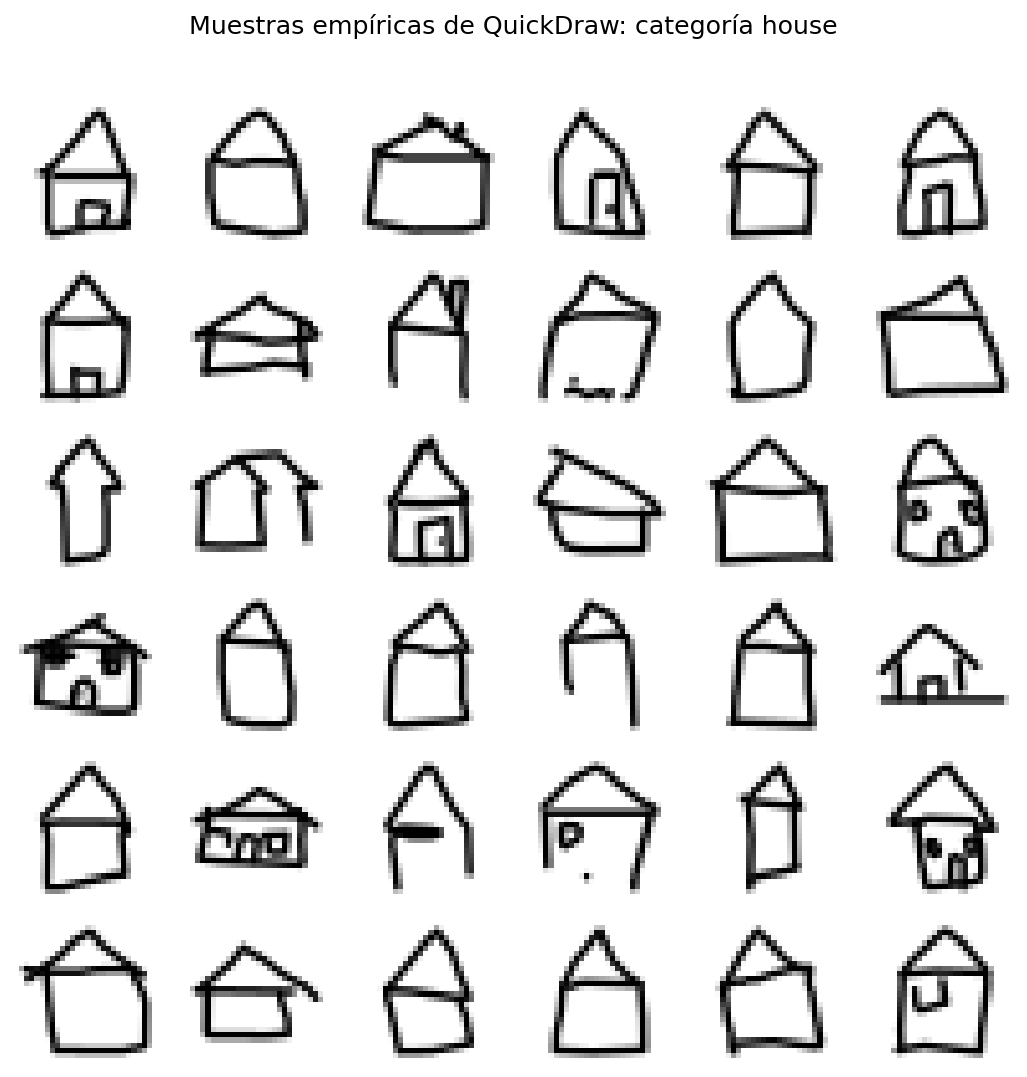

In [3]:
def mostrar_grilla(images, n=36, seed=0, title=None):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(images), size=n, replace=False)
    cols = int(np.sqrt(n))
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.25, rows * 1.25))
    axes = np.asarray(axes).ravel()
    for ax, image in zip(axes, images[idx]):
        ax.imshow(image, vmin=0, vmax=255)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    if title:
        fig.suptitle(title, y=1.02, fontsize=13)
    fig.tight_layout()


mostrar_grilla(x_train, n=36, seed=11, title="Muestras empíricas de QuickDraw: categoría house")

## Representación vectorial de imágenes

Aunque visualmente interpretamos cada observación como un dibujo, el computador almacena la imagen como una matriz de números. Para un modelo neuronal, esa matriz puede procesarse como arreglo bidimensional, como tensor con canal, o como vector aplanado. Esta equivalencia es importante porque permite conectar la intuición visual con el espacio matemático donde ocurre el aprendizaje.

Una imagen de `28x28` contiene $28 \cdot 28 = 784$ valores. Al aplanarla, obtenemos un punto en $\mathbb{R}^{784}$. La distribución de casas no es una distribución sobre objetos simbólicos llamados “casas”; es una distribución sobre configuraciones de 784 intensidades.

Forma matricial: (28, 28)
Forma vectorial: (784,)
Ventana visualizada: coordenadas 0 a 783


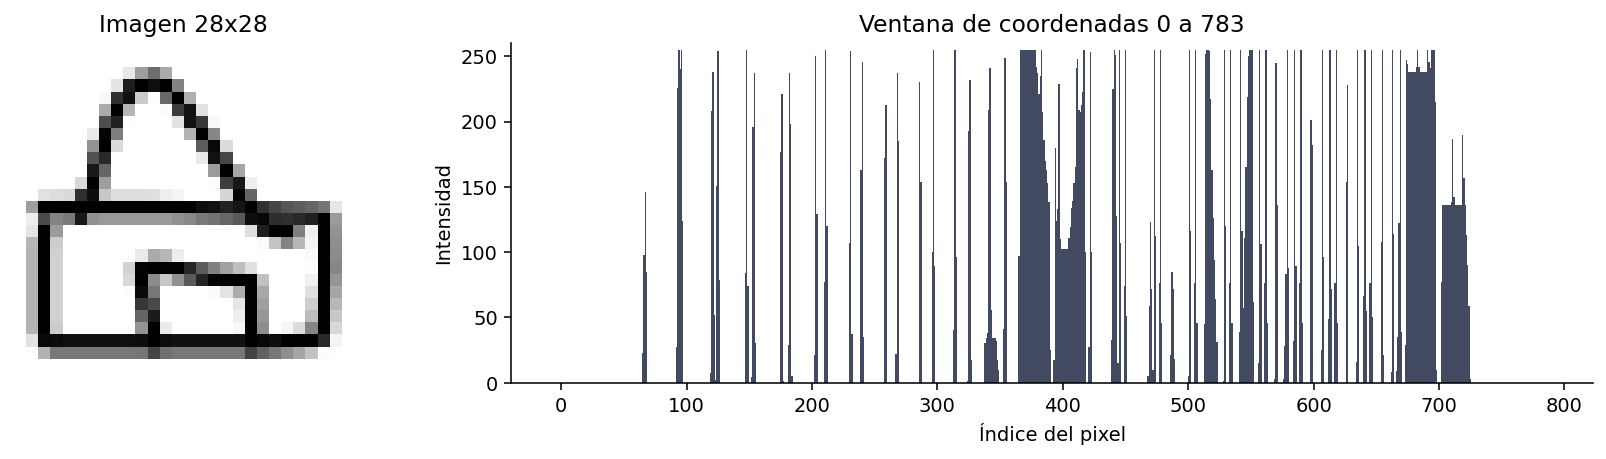

In [4]:
image = x_train[0]
vector = image.reshape(-1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [1.1, 2.6]})

axes[0].imshow(image, vmin=0, vmax=255)
axes[0].set_title("Imagen 28x28")
axes[0].axis("off")


start = 0
end = 784
coords = np.arange(start, end)
axes[1].bar(coords, vector[start:end], width=1.0, color="#1f2a44", alpha=0.85)
axes[1].set_title(f"Ventana de coordenadas {start} a {end - 1}")
axes[1].set_xlabel("Índice del pixel")
axes[1].set_ylabel("Intensidad")
axes[1].set_ylim(0, 260)

fig.tight_layout()

print(f"Forma matricial: {image.shape}")
print(f"Forma vectorial: {vector.shape}")
print(f"Ventana visualizada: coordenadas {start} a {end - 1}")


Esta representación no significa que la estructura espacial deje de importar. De hecho, las arquitecturas convolucionales y U-Net explotan la organización local de los pixeles. Pero desde el punto de vista probabilístico, seguimos tratando con una variable aleatoria de alta dimensión. Este punto será esencial cuando introduzcamos ruido gaussiano: el ruido también será una muestra en ese mismo espacio de dimensión $784$.

## Muestreo empírico y memorización

Antes de entrenar cualquier modelo, ya existe una forma trivial de “generar” una casa: escoger una imagen aleatoria del dataset. Este procedimiento produce muestras válidas, pero no aprende una regla generativa. Solo reutiliza observaciones existentes.

Podemos formalizar este procedimiento mediante la distribución empírica:

$$
\hat{p}_{\mathrm{data}}(x) = \frac{1}{N}\sum_{i=1}^{N} \delta(x - x_i),
$$

donde $\delta$ representa una masa puntual en cada observación del dataset. Muestrear de $\hat{p}_{\mathrm{data}}$ equivale a seleccionar uno de los ejemplos almacenados.

Esta distribución empírica es útil para describir lo observado, pero no resuelve el problema generativo en sentido fuerte. Un modelo generativo debe capturar regularidades que le permitan producir muestras nuevas, no solamente recuperar índices del conjunto de entrenamiento.

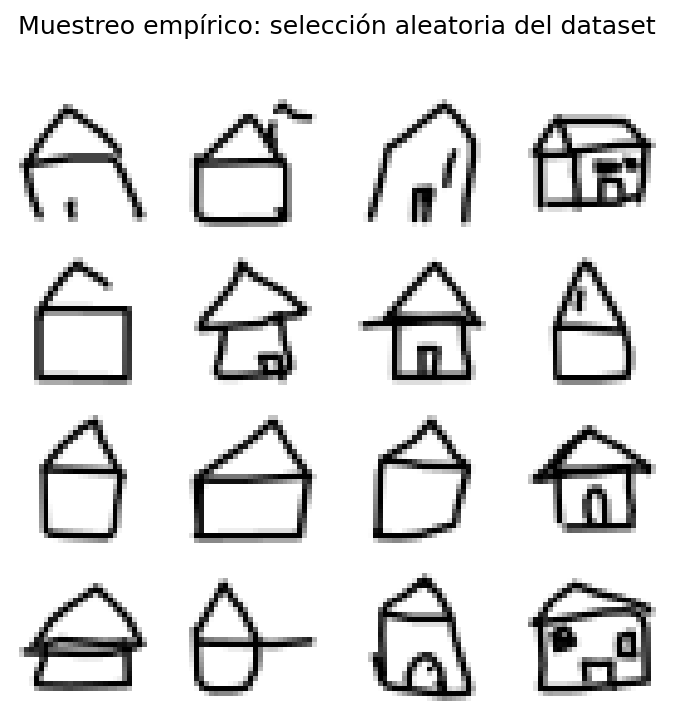

In [5]:
def muestreador_empirico(images, n=16, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(images), size=n, replace=False)
    return images[idx]

muestras_empiricas = muestreador_empirico(x_train, n=16, seed=123)
mostrar_grilla(muestras_empiricas, n=16, seed=0, title="Muestreo empírico: selección aleatoria del dataset")

El muestreo empírico establece una línea base conceptual. Generar no debe confundirse con acceder a una base de datos y devolver un elemento. En los modelos de difusión, el punto de partida será distinto: se comenzará con ruido y se aplicará una dinámica aprendida para producir una muestra plausible.

## Estructura estadística de la muestra

Aunque no conocemos $p_{\mathrm{data}}(x)$, podemos estimar propiedades empíricas de la muestra. Estas propiedades no son el modelo generativo, pero revelan regularidades que cualquier modelo razonable debería capturar.

Dos cantidades simples son el promedio y la desviación estándar empírica pixel a pixel:

$$
\bar{x} = \frac{1}{N}\sum_{i=1}^{N} x_i,
$$

$$
\hat{\sigma} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_i - \bar{x})^2}.
$$

Aquí $\bar{x}, \hat{\sigma} \in \mathbb{R}^{28 \times 28}$. Es decir, no son escalares: son imágenes-resumen. El promedio no es una casa generada; es un resumen estadístico. Sin embargo, permite observar zonas donde muchas casas concentran trazos: regiones asociadas al techo, paredes o base. La desviación estándar muestra dónde hay mayor variabilidad entre dibujantes.

Media de intensidad total: 135.43
Desviación estándar:       26.10


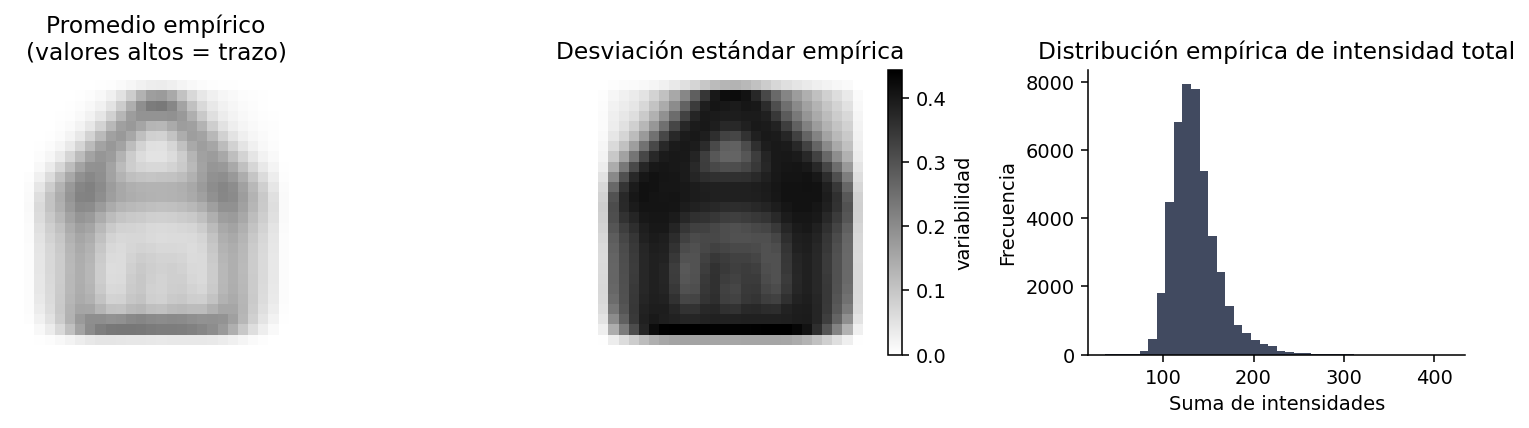

In [6]:
x_float = x_train.astype(np.float32) / 255.0
mean_image = x_float.mean(axis=0)
std_image = x_float.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
axes[0].imshow(mean_image, vmin=0, vmax=1)
axes[0].set_title("Promedio empírico\n(valores altos = trazo)")
axes[0].axis("off")

im = axes[1].imshow(std_image, vmin=0, vmax=std_image.max())
axes[1].set_title("Desviación estándar empírica")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="variabilidad")

# QuickDraw bitmap representa los trazos con intensidades altas sobre fondo bajo.
# La suma total de intensidad funciona como estadístico simple del dibujo.
ink_mass = x_float.sum(axis=(1, 2))
axes[2].hist(ink_mass, bins=40, color="#1f2a44", alpha=0.85)
axes[2].set_title("Distribución empírica de intensidad total")
axes[2].set_xlabel("Suma de intensidades")
axes[2].set_ylabel("Frecuencia")

fig.tight_layout()

print(f"Media de intensidad total: {ink_mass.mean():.2f}")
print(f"Desviación estándar:       {ink_mass.std():.2f}")

Estas visualizaciones muestran una propiedad central de los datos: la distribución no es uniforme sobre todas las imágenes posibles. La mayoría de las configuraciones de 784 pixeles no se parecen a una casa. Las muestras del dataset ocupan una región altamente estructurada del espacio de datos.

Esta observación motiva el problema generativo. Si pudiéramos describir explícitamente esa región estructurada, podríamos muestrear nuevas casas directamente. Como no conocemos esa descripción, entrenaremos modelos que la aproximen.

## Contraste con ruido gaussiano

Una distribución simple como la gaussiana estándar es fácil de muestrear:

$$
z \sim \mathcal{N}(0, I).
$$

Si generamos vectores gaussianos en $\mathbb{R}^{784}$ y los reorganizamos como imágenes de `28x28`, obtenemos patrones sin estructura semántica. Esto no es un defecto del ruido; es precisamente la razón por la que resulta útil. El ruido proporciona una distribución inicial conocida, simple y reproducible.

El objetivo de los modelos de difusión será aprender un procedimiento que conecte esa distribución simple con la distribución compleja de datos.

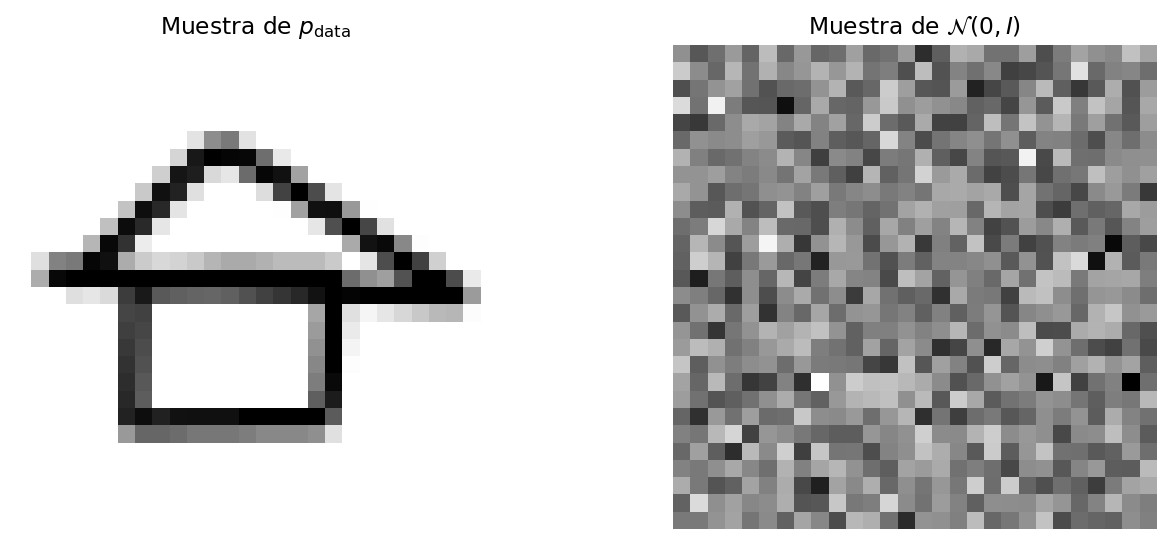

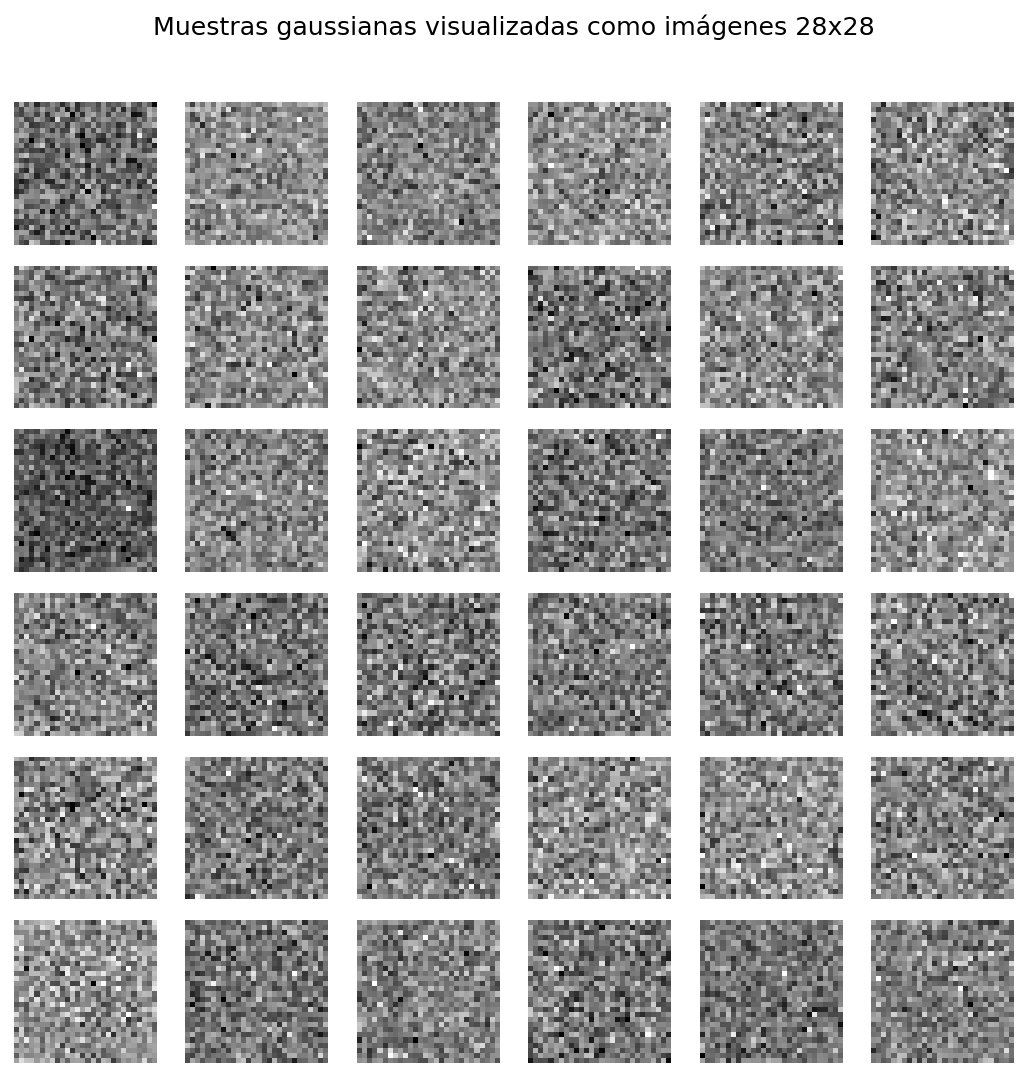

In [7]:
def muestras_gaussianas_como_imagenes(n=36, seed=0):
    rng = np.random.default_rng(seed)
    z = rng.normal(loc=0.0, scale=1.0, size=(n, 28, 28))
    # Reescalado solo para visualización: cada muestra se lleva a [0, 1].
    z_min = z.min(axis=(1, 2), keepdims=True)
    z_max = z.max(axis=(1, 2), keepdims=True)
    z_vis = (z - z_min) / (z_max - z_min + 1e-8)
    return z_vis

noise_images = muestras_gaussianas_como_imagenes(n=36, seed=19)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(x_train[5], vmin=0, vmax=255)
axes[0].set_title(r"Muestra de $p_{\mathrm{data}}$")
axes[0].axis("off")

axes[1].imshow(noise_images[0], vmin=0, vmax=1)
axes[1].set_title(r"Muestra de $\mathcal{N}(0, I)$")
axes[1].axis("off")
fig.tight_layout()

mostrar_grilla((noise_images * 255).astype(np.uint8), n=36, seed=0, title="Muestras gaussianas visualizadas como imágenes 28x28")

La comparación anterior debe leerse en términos de distribuciones. Tanto una casa como una imagen de ruido son arreglos de `28x28` números. La diferencia no está en el tipo de objeto computacional, sino en la distribución de la que provienen.

Esta es una idea decisiva: el modelo generativo no cambia el espacio de representación. Cambia la forma en que se muestrean puntos dentro de ese espacio.

## Proyección de la muestra en dos dimensiones

El espacio real de datos tiene $784$ dimensiones, lo cual impide visualizar directamente la geometría de la muestra. Podemos, sin embargo, proyectar un subconjunto a dos dimensiones mediante PCA. Esta proyección no preserva toda la información, pero ayuda a observar que las imágenes no se distribuyen como ruido arbitrario.

Para que el contraste no dependa solamente de diferencias de escala, estandarizaremos los pixeles antes de calcular la proyección: cada coordenada se centra y se divide por su desviación estándar empírica. Luego compararemos los datos estandarizados contra ruido gaussiano estándar en esos mismos ejes principales. La visualización sigue siendo cualitativa; no pretende probar que conocemos $p_{\mathrm{data}}$, sino mostrar una diferencia estructural entre datos y ruido.

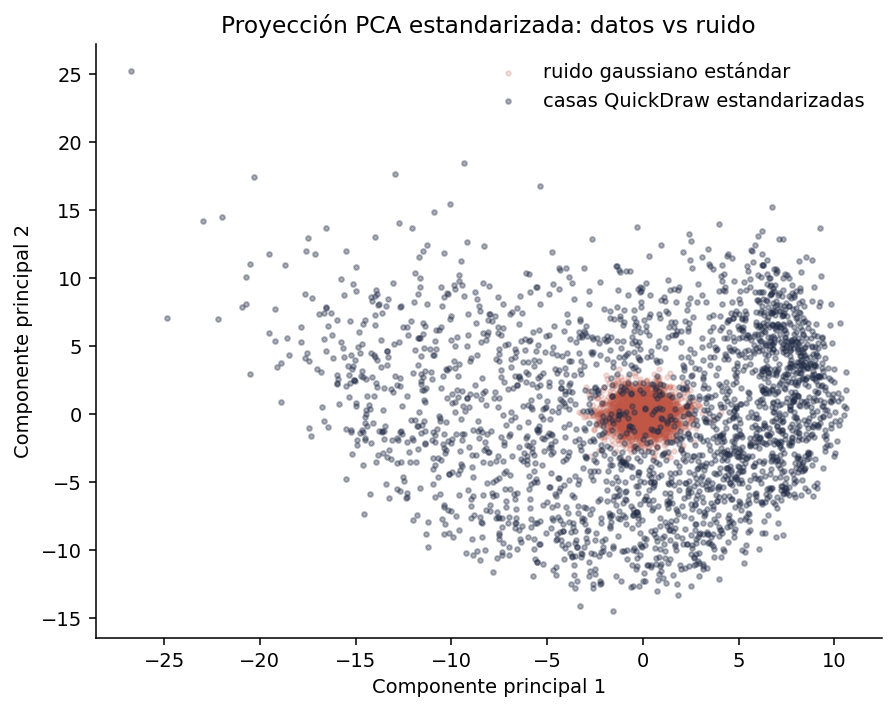

In [8]:
n_pca = 2500
idx = RNG.choice(len(x_train), size=n_pca, replace=False)
X_data = x_train[idx].reshape(n_pca, -1).astype(np.float32) / 255.0

pixel_mean = X_data.mean(axis=0, keepdims=True)
pixel_std = X_data.std(axis=0, keepdims=True) + 1e-6
X_data_std = (X_data - pixel_mean) / pixel_std
X_noise_std = RNG.normal(size=X_data_std.shape).astype(np.float32)

# Estimamos los ejes principales sobre los datos estandarizados y proyectamos
# ruido estándar sobre esos mismos ejes. Así evitamos que la comparación se deba
# solamente a diferencias de escala entre pixeles y ruido.
X_centered = X_data_std - X_data_std.mean(axis=0, keepdims=True)
_, _, vt = np.linalg.svd(X_centered, full_matrices=False)
components = vt[:2]
proj_data = X_centered @ components.T
proj_noise = X_noise_std @ components.T

fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.scatter(proj_noise[:, 0], proj_noise[:, 1], s=6, alpha=0.18, label="ruido gaussiano estándar", color="#c05746")
ax.scatter(proj_data[:, 0], proj_data[:, 1], s=6, alpha=0.35, label="casas QuickDraw estandarizadas", color="#1f2a44")
ax.set_title("Proyección PCA estandarizada: datos vs ruido")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.legend(frameon=False)
fig.tight_layout()

La proyección confirma, de forma limitada pero útil, que las muestras de casas y las muestras gaussianas tienen comportamientos distintos incluso después de controlar la escala de los pixeles. La tarea de un modelo generativo será aprender una forma de producir puntos que caigan en regiones con estructura de datos, no en regiones arbitrarias del espacio.

## Síntesis

**Resultado conceptual.** Un conjunto de datos puede interpretarse como una muestra empírica de una distribución desconocida. En QuickDraw, cada dibujo de casa es una realización de una variable aleatoria de alta dimensión. Por tanto, el objetivo de un modelo generativo no es memorizar ejemplos individuales, sino aproximar la distribución que hace plausibles esas observaciones.

La formulación básica queda resumida por

$$
\mathcal{D} = \{x_i\}_{i=1}^{N},
\qquad
x_i \sim p_{\mathrm{data}}(x),
\qquad
p_\theta(x) \approx p_{\mathrm{data}}(x).
$$

En términos computacionales, cada muestra $x_i$ corresponde a una imagen `28x28`, o equivalentemente a un vector en $\mathbb{R}^{784}$. Las visualizaciones del notebook muestran que esa distribución empírica posee estructura: sus muestras no se comportan como vectores gaussianos independientes sin transformar.

El resto de la primera parte del curso tomará la lectura discreta del mapa inicial: estudiar ruido gaussiano, definir una corrupción progresiva por pasos y convertir la generación en un problema de denoising aprendido.


## Preguntas de discusión

1. ¿Por qué no basta con decir que el modelo aprende “imágenes de casas”?
2. ¿Qué diferencia hay entre muestrear de la distribución empírica $\hat{p}_{\mathrm{data}}$ y aprender un modelo generativo $p_\theta$?
3. ¿Qué información se pierde cuando resumimos el dataset mediante una imagen promedio?
4. ¿Por qué el ruido gaussiano es un punto de partida útil aunque no tenga estructura visual?
5. ¿Qué debería significar, en este contexto, que una muestra generada sea “plausible”?

## Continuidad

El siguiente notebook estudiará el ruido gaussiano como distribución de referencia en espacios de datos. La pregunta que abre esa discusión es directa: si las muestras de ruido no tienen estructura visual, ¿por qué tantos modelos generativos modernos comienzan precisamente desde ruido?

Responder esa pregunta permitirá introducir la idea central de los modelos de difusión: construir un puente entre una distribución simple, fácil de muestrear, y una distribución estructurada de datos.